In [34]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Preprocessing pipeline
transform = transforms.Compose([
    transforms.Resize((224, 224)),   # resize all images
    transforms.ToTensor(),           # convert to tensor
    transforms.Normalize(            # normalize using ImageNet stats
        mean=[0.485, 0.456, 0.406], 
        std=[0.229, 0.224, 0.225]
    )
])

# Dataset paths
train_dir = "Training"
val_dir = "Validation"

# Load datasets
train_dataset = datasets.ImageFolder(root=train_dir, transform=transform)
val_dataset = datasets.ImageFolder(root=val_dir, transform=transform)

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

# Test one batch
images, labels = next(iter(train_loader))
print("Batch images shape:", images.shape)
print("Batch labels:", labels[:10])


Train samples: 1525
Validation samples: 371
Batch images shape: torch.Size([32, 3, 224, 224])
Batch labels: tensor([0, 1, 0, 1, 1, 1, 1, 1, 1, 1])


In [35]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
import os


In [36]:
# Data augmentation for training
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Validation (no augmentation, only resize + normalize)
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Dataset paths
train_dir = "Training"
val_dir   = "Validation"

train_data = datasets.ImageFolder(train_dir, transform=train_transforms)
val_data   = datasets.ImageFolder(val_dir, transform=val_transforms)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_data, batch_size=32, shuffle=False, num_workers=2)

print(f"Train samples: {len(train_data)}")
print(f"Validation samples: {len(val_data)}")

# Test a batch
images, labels = next(iter(train_loader))
print("Batch images shape:", images.shape)
print("Batch labels:", labels[:10])


Train samples: 1525
Validation samples: 371
Batch images shape: torch.Size([32, 3, 224, 224])
Batch labels: tensor([1, 1, 1, 0, 1, 0, 0, 0, 1, 1])


In [37]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Load pretrained ResNet18
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Replace final layer with Dropout + Linear
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_features, 2)  # binary classification (real/fake)
)

model = model.to(device)


Using device: cuda


In [38]:
criterion = nn.CrossEntropyLoss()

# Adam optimizer with weight decay (L2 regularization)
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

# Reduce LR when val_loss plateaus
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)


In [39]:
# Track metrics for plotting
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}


In [40]:
epochs = 20
best_val_acc = 0.0

for epoch in range(epochs):
    # ------------------- Training -------------------
    model.train()
    train_loss, correct, total = 0, 0, 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    
    train_acc = 100 * correct / total
    avg_train_loss = train_loss / len(train_loader)
    
    # ------------------- Validation -------------------
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
    
    val_acc = 100 * val_correct / val_total
    avg_val_loss = val_loss / len(val_loader)

    # Scheduler step
    scheduler.step(avg_val_loss)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")
        print(" Saved best model with val_acc:", best_val_acc)

    # Save metrics in history
    history["train_loss"].append(avg_train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(avg_val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.2f}%")


 Saved best model with val_acc: 83.01886792452831
Epoch [1/20] | Train Loss: 0.5580, Train Acc: 71.93% | Val Loss: 0.4131, Val Acc: 83.02%
 Saved best model with val_acc: 86.79245283018868
Epoch [2/20] | Train Loss: 0.3418, Train Acc: 85.05% | Val Loss: 0.3301, Val Acc: 86.79%
 Saved best model with val_acc: 87.06199460916442
Epoch [3/20] | Train Loss: 0.3403, Train Acc: 84.98% | Val Loss: 0.4029, Val Acc: 87.06%
 Saved best model with val_acc: 92.18328840970351
Epoch [4/20] | Train Loss: 0.3158, Train Acc: 87.02% | Val Loss: 0.2123, Val Acc: 92.18%
Epoch [5/20] | Train Loss: 0.2428, Train Acc: 89.64% | Val Loss: 0.1999, Val Acc: 91.37%
Epoch [6/20] | Train Loss: 0.2263, Train Acc: 90.95% | Val Loss: 0.2868, Val Acc: 89.49%
Epoch [7/20] | Train Loss: 0.2217, Train Acc: 90.95% | Val Loss: 0.1673, Val Acc: 90.84%
Epoch [8/20] | Train Loss: 0.1990, Train Acc: 91.61% | Val Loss: 0.4150, Val Acc: 89.49%
 Saved best model with val_acc: 93.80053908355795
Epoch [9/20] | Train Loss: 0.2193, Tra

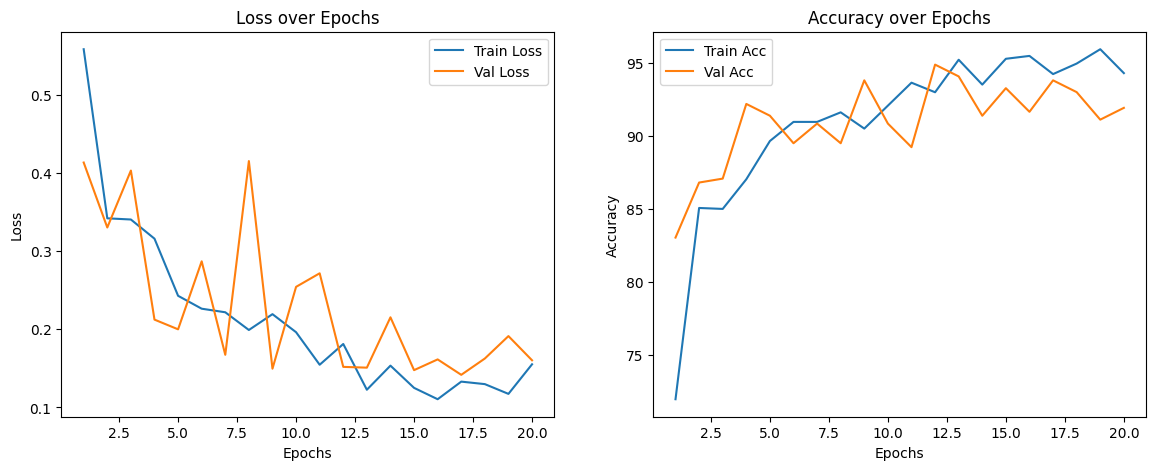

In [41]:
import matplotlib.pyplot as plt

def plot_training(history):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(14,5))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(epochs, history['train_loss'], label="Train Loss")
    plt.plot(epochs, history['val_loss'], label="Val Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Loss over Epochs")
    plt.legend()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(epochs, history['train_acc'], label="Train Acc")
    plt.plot(epochs, history['val_acc'], label="Val Acc")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title("Accuracy over Epochs")
    plt.legend()

    plt.show()

plot_training(history)


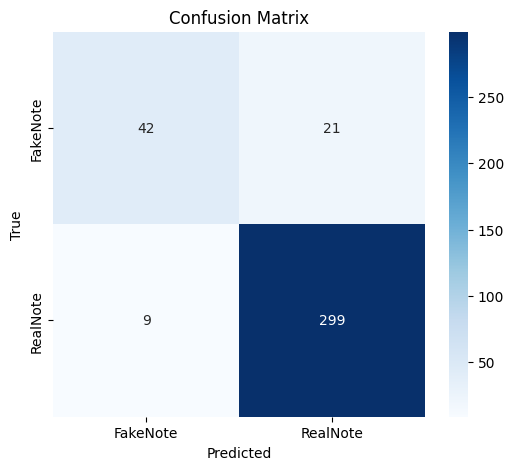


Classification Report:

              precision    recall  f1-score   support

    FakeNote       0.82      0.67      0.74        63
    RealNote       0.93      0.97      0.95       308

    accuracy                           0.92       371
   macro avg       0.88      0.82      0.84       371
weighted avg       0.92      0.92      0.92       371



In [42]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Get all predictions
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
classes = val_dataset.classes

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=classes))


C:\Users\pavan\AppData\Roaming\Python\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\pavan\AppData\Roaming\Python\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


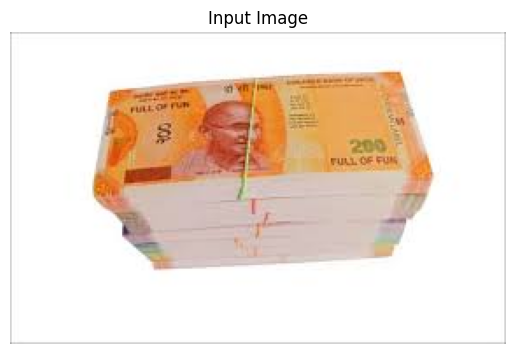

Prediction from Local Path: Fake, Confidence: 0.68


In [1]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt
import os

# Device setup (GPU if available, else CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained model (for demo, fine-tune with your dataset later)
model = models.resnet18(pretrained=True)
num_ftrs = model.fc.in_features
model.fc = torch.nn.Linear(num_ftrs, 2)  # 2 classes: Real or Fake

# If you have trained weights, load them here
# model.load_state_dict(torch.load("best_model.pth", map_location=device))

model = model.to(device)
model.eval()

# Image preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Prediction function for both URL and local path
def predict_note(img_path_or_url):
    # Check if it's a URL or local file path
    if img_path_or_url.startswith("http://") or img_path_or_url.startswith("https://"):
        response = requests.get(img_path_or_url)
        img = Image.open(BytesIO(response.content)).convert("RGB")
    else:
        if not os.path.exists(img_path_or_url):
            raise FileNotFoundError(f"File not found: {img_path_or_url}")
        img = Image.open(img_path_or_url).convert("RGB")

    # Show image
    plt.imshow(img)
    plt.axis("off")
    plt.title("Input Image")
    plt.show()

    # Preprocess image
    img_tensor = transform(img).unsqueeze(0).to(device)

    # Model prediction
    with torch.no_grad():
        outputs = model(img_tensor)
        probs = torch.softmax(outputs, dim=1)
        conf, pred = torch.max(probs, 1)

    # Convert prediction to label
    label = "Real" if pred.item() == 1 else "Fake"
    return label, conf.item()

# Example usage with URL
#label, confidence = predict_note("https://akm-img-a-in.tosshub.com/sites/media2/indiatoday/images/stories/Anjali/090206091111_Ori_large.jpg")
#print(f"Prediction from URL: {label}, Confidence: {confidence:.2f}")

# Example usage with local file
label, confidence = predict_note(r"C:\Users\pavan\OneDrive\Documents\Desktop\200\fake6 200rps.jpeg")
print(f"Prediction from Local Path: {label}, Confidence: {confidence:.2f}")
